In [1]:
import tensorflow as tf

# Check if the GPU is recognized
gpu_available = tf.config.list_physical_devices('GPU')

print("Num GPUs Available: ", len(gpu_available))
if gpu_available:
    print("Success! TensorFlow is using the GPU.")
    # This prints the name of your GPU (e.g., RTX 3060)
    print("Device Name:", gpu_available[0].name)
else:
    print("Failure. TensorFlow is still using the CPU.")



Num GPUs Available:  1
Success! TensorFlow is using the GPU.
Device Name: /physical_device:GPU:0


In [4]:
import numpy as np

# 1. Load the compressed file
data = np.load('cs_dataset_final_justgo.npz')

# 2. Extract the arrays into X and Y
X = data['X']
Y = data['Y']

# 3. Verify the shapes
print(f"X shape: {X.shape}") # Should be (Samples, 4)
print(f"Y shape: {Y.shape}") # Should be (Samples, 2)

X shape: (8716, 4)
Y shape: (8716, 2)



--- Starting High-Precision GPU Training ---
Epoch 1/1000
218/218 [==============================] - 2s 4ms/step - loss: 0.7464 - mae: 0.6342 - val_loss: 0.5136 - val_mae: 0.5054
Epoch 2/1000
218/218 [==============================] - 1s 4ms/step - loss: 0.5520 - mae: 0.5180 - val_loss: 0.4867 - val_mae: 0.4858
Epoch 3/1000
218/218 [==============================] - 1s 3ms/step - loss: 0.5179 - mae: 0.4918 - val_loss: 0.4498 - val_mae: 0.4584
Epoch 4/1000
218/218 [==============================] - 1s 3ms/step - loss: 0.4768 - mae: 0.4565 - val_loss: 0.4129 - val_mae: 0.4276
Epoch 5/1000
218/218 [==============================] - 1s 3ms/step - loss: 0.4400 - mae: 0.4254 - val_loss: 0.3768 - val_mae: 0.3826
Epoch 6/1000
218/218 [==============================] - 1s 3ms/step - loss: 0.4123 - mae: 0.3976 - val_loss: 0.3562 - val_mae: 0.3695
Epoch 7/1000
218/218 [==============================] - 1s 3ms/step - loss: 0.3937 - mae: 0.3838 - val_loss: 0.3429 - val_mae: 0.3607
Epoch 8/1000
218

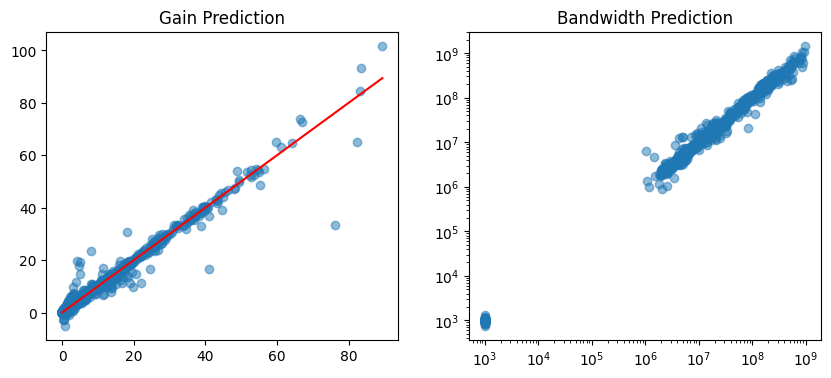

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.io import loadmat
import matplotlib.pyplot as plt

# --- STEP 1: LOAD MATLAB DATA ---
data = np.load('cs_dataset_final_justgo.npz')

# 2. Extract the arrays into X and Y
X = data['X']
Y = data['Y']

# --- STEP 2: LOG-TRANSFORM (Exact MATLAB Logic) ---
X_log = np.zeros_like(X)
X_log[:, 0] = np.log10(X[:, 0]) # Rd
X_log[:, 1] = np.log10(X[:, 1]) # Wn
X_log[:, 2] = X[:, 2]           # VG (Linear)
X_log[:, 3] = np.log10(X[:, 3]) # Ln

Y_log = np.zeros_like(Y)
Y_log[:, 0] = Y[:, 0]           # Gain (Linear)
Y_log[:, 1] = np.log10(Y[:, 1]) # BW

# --- STEP 3: NORMALIZE & SPLIT ---
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

Xn = scaler_X.fit_transform(X_log)
Yn = scaler_Y.fit_transform(Y_log)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(Xn, Yn, test_size=0.2, random_state=1)

# --- STEP 4: THE ACCURACY DNN ---
model = models.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='tanh'), # Tanh is often smoother for analog regression
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(2)
])

# --- STEP 5: PRECISION SETTINGS ---
# Lower learning rate = higher precision
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001) 

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Stop training if the validation loss doesn't improve for 50 epochs
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

print("\n--- Starting High-Precision GPU Training ---")
history = model.fit(
    Xtrain, Ytrain,
    epochs=1000, 
    batch_size=32,      # Smaller batch = higher accuracy updates
    validation_data=(Xtest, Ytest),
    callbacks=[early_stop],
    verbose=1
)

# --- STEP 6: EVALUATION ---
Ypred_n = model.predict(Xtest)
Ypred_log = scaler_Y.inverse_transform(Ypred_n)
Ytest_actual_log = scaler_Y.inverse_transform(Ytest)

GAIN_pred = Ypred_log[:, 0]
GAIN_true = Ytest_actual_log[:, 0]
BW_pred   = 10**(Ypred_log[:, 1])
BW_true   = 10**(Ytest_actual_log[:, 1])

# ERROR METRICS
gain_rmse = np.sqrt(np.mean((GAIN_pred - GAIN_true)**2))
bw_relerr = np.mean(np.abs(BW_pred - BW_true) / BW_true) * 100

print(f'\n--- FINAL RESULTS ---')
print(f'GAIN RMSE = {gain_rmse:.4f}')
print(f'BW Mean Relative Error = {bw_relerr:.2f} %')

# --- STEP 7: PLOTS ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(GAIN_true, GAIN_pred, alpha=0.5)
plt.plot([GAIN_true.min(), GAIN_true.max()], [GAIN_true.min(), GAIN_true.max()], 'r')
plt.title('Gain Prediction')

plt.subplot(1, 2, 2)
plt.scatter(BW_true, BW_pred, alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.title('Bandwidth Prediction')
plt.show()

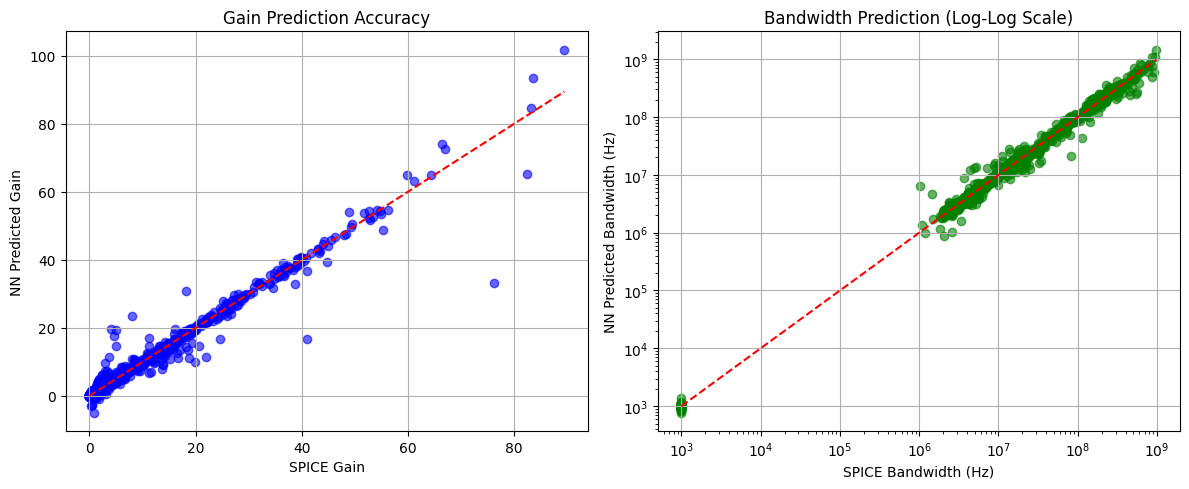

In [10]:
# --- STEP 10: Plots (Thesis-Ready) ---
plt.figure(figsize=(12, 5))

# Gain Plot
plt.subplot(1, 2, 1)
plt.scatter(GAIN_true, GAIN_pred, alpha=0.6, color='blue')
plt.plot([GAIN_true.min(), GAIN_true.max()], [GAIN_true.min(), GAIN_true.max()], 'r--')
plt.xlabel('SPICE Gain')
plt.ylabel('NN Predicted Gain')
plt.title('Gain Prediction Accuracy')
plt.grid(True)

# BW Plot
plt.subplot(1, 2, 2)
plt.scatter(BW_true, BW_pred, alpha=0.6, color='green')
plt.xscale('log')
plt.yscale('log')
plt.plot([BW_true.min(), BW_true.max()], [BW_true.min(), BW_true.max()], 'r--')
plt.xlabel('SPICE Bandwidth (Hz)')
plt.ylabel('NN Predicted Bandwidth (Hz)')
plt.title('Bandwidth Prediction (Log-Log Scale)')
plt.grid(True)

plt.tight_layout()
plt.show()



In [11]:
import joblib
import os

# 1. Save the DNN (The Layers and Weights)
model.save("my_analog_surrogate_model_tanh_test_python_data.h5")

# 2. Save the Scalers (The mu and sigma values)
# These are the equivalent of your MATLAB Xmu, Xsigma, Ymu, Ysigma
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_Y, "scaler_Y.pkl")

print("-" * 30)
print("SUCCESS: DNN and Scalers are saved!")
print(f"Check this folder: {os.getcwd()}")
print("You should see:my_analog_surrogate_model_tanh_test_python_data.h5, scaler_X.pkl, scaler_Y.pkl")
print("-" * 30)

------------------------------
SUCCESS: DNN and Scalers are saved!
Check this folder: C:\Users\Mohamed\Desktop\ML\Redo_project
You should see:my_analog_surrogate_model_tanh_test_python_data.h5, scaler_X.pkl, scaler_Y.pkl
------------------------------



--- Starting High-Precision GPU Training ---
Epoch 1/1000
218/218 [==============================] - 1s 4ms/step - loss: 0.8430 - mae: 0.7017 - val_loss: 0.5774 - val_mae: 0.5422
Epoch 2/1000
218/218 [==============================] - 1s 3ms/step - loss: 0.5418 - mae: 0.4919 - val_loss: 0.4463 - val_mae: 0.4532
Epoch 3/1000
218/218 [==============================] - 1s 4ms/step - loss: 0.4655 - mae: 0.4495 - val_loss: 0.4087 - val_mae: 0.4246
Epoch 4/1000
218/218 [==============================] - 1s 5ms/step - loss: 0.4305 - mae: 0.4238 - val_loss: 0.3840 - val_mae: 0.4042
Epoch 5/1000
218/218 [==============================] - 1s 4ms/step - loss: 0.4040 - mae: 0.4033 - val_loss: 0.3599 - val_mae: 0.3805
Epoch 6/1000
218/218 [==============================] - 1s 4ms/step - loss: 0.3811 - mae: 0.3840 - val_loss: 0.3390 - val_mae: 0.3597
Epoch 7/1000
218/218 [==============================] - 1s 4ms/step - loss: 0.3595 - mae: 0.3647 - val_loss: 0.3194 - val_mae: 0.3404
Epoch 8/1000
218

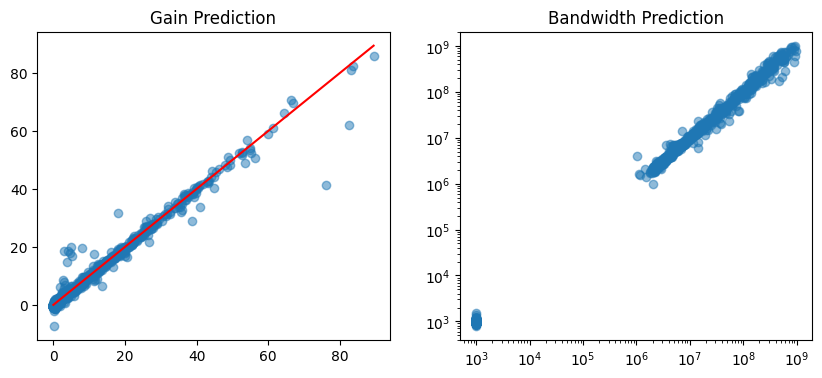

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.io import loadmat
import matplotlib.pyplot as plt

# --- STEP 1: LOAD MATLAB DATA ---
data = np.load('cs_dataset_final_justgo.npz')

# 2. Extract the arrays into X and Y
X = data['X']
Y = data['Y']

# --- STEP 2: LOG-TRANSFORM (Exact MATLAB Logic) ---
X_log = np.zeros_like(X)
X_log[:, 0] = np.log10(X[:, 0]) # Rd
X_log[:, 1] = np.log10(X[:, 1]) # Wn
X_log[:, 2] = X[:, 2]           # VG (Linear)
X_log[:, 3] = np.log10(X[:, 3]) # Ln

Y_log = np.zeros_like(Y)
Y_log[:, 0] = Y[:, 0]           # Gain (Linear)
Y_log[:, 1] = np.log10(Y[:, 1]) # BW

# --- STEP 3: NORMALIZE & SPLIT ---
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

Xn = scaler_X.fit_transform(X_log)
Yn = scaler_Y.fit_transform(Y_log)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(Xn, Yn, test_size=0.2, random_state=1)

# --- STEP 4: THE ACCURACY DNN ---
model = models.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='relu'), # Tanh is often smoother for analog regression
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)
])

# --- STEP 5: PRECISION SETTINGS ---
# Lower learning rate = higher precision
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001) 

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Stop training if the validation loss doesn't improve for 50 epochs
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

print("\n--- Starting High-Precision GPU Training ---")
history = model.fit(
    Xtrain, Ytrain,
    epochs=1000, 
    batch_size=32,      # Smaller batch = higher accuracy updates
    validation_data=(Xtest, Ytest),
    callbacks=[early_stop],
    verbose=1
)

# --- STEP 6: EVALUATION ---
Ypred_n = model.predict(Xtest)
Ypred_log = scaler_Y.inverse_transform(Ypred_n)
Ytest_actual_log = scaler_Y.inverse_transform(Ytest)

GAIN_pred = Ypred_log[:, 0]
GAIN_true = Ytest_actual_log[:, 0]
BW_pred   = 10**(Ypred_log[:, 1])
BW_true   = 10**(Ytest_actual_log[:, 1])

# ERROR METRICS
gain_rmse = np.sqrt(np.mean((GAIN_pred - GAIN_true)**2))
bw_relerr = np.mean(np.abs(BW_pred - BW_true) / BW_true) * 100

print(f'\n--- FINAL RESULTS ---')
print(f'GAIN RMSE = {gain_rmse:.4f}')
print(f'BW Mean Relative Error = {bw_relerr:.2f} %')

# --- STEP 7: PLOTS ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(GAIN_true, GAIN_pred, alpha=0.5)
plt.plot([GAIN_true.min(), GAIN_true.max()], [GAIN_true.min(), GAIN_true.max()], 'r')
plt.title('Gain Prediction')

plt.subplot(1, 2, 2)
plt.scatter(BW_true, BW_pred, alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.title('Bandwidth Prediction')
plt.show()

In [14]:
import joblib
import os

# 1. Save the DNN (The Layers and Weights)
model.save("my_analog_surrogate_model_relu_test_python_data.h5")

# 2. Save the Scalers (The mu and sigma values)
# These are the equivalent of your MATLAB Xmu, Xsigma, Ymu, Ysigma
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_Y, "scaler_Y.pkl")

print("-" * 30)
print("SUCCESS: DNN and Scalers are saved!")
print(f"Check this folder: {os.getcwd()}")
print("You should see:my_analog_surrogate_model_relu_test_python_data.h5, scaler_X.pkl, scaler_Y.pkl")
print("-" * 30)

------------------------------
SUCCESS: DNN and Scalers are saved!
Check this folder: C:\Users\Mohamed\Desktop\ML\Redo_project
You should see:my_analog_surrogate_model_relu_test_python_data.h5, scaler_X.pkl, scaler_Y.pkl
------------------------------
